## 📦 1. Import Library & Setup Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, mean_absolute_error, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch & Transformers
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
print(f'📦 PyTorch version: {torch.__version__}')
print('✅ Semua library berhasil diimport!')

🖥️  Device: cpu
📦 PyTorch version: 2.12.0+cpu
✅ Semua library berhasil diimport!


---
## 📊 2. Load Dataset & Exploratory Data Analysis (EDA)

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
DATA_PATH = Path('..') / '..' / 'DS' / 'Emotion Label' / 'Emotion Dataset Merged.xlsx'

print(f'📁 Loading dataset from: {DATA_PATH}')
df = pd.read_excel(DATA_PATH)

print('=' * 55)
print('📋 INFORMASI DATASET')
print('=' * 55)
print(f'  Total sampel  : {len(df):,}')
print(f'  Jumlah kolom  : {len(df.columns)}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print()
print('📌 Kolom:', df.columns.tolist())
print()
df.head()

📁 Loading dataset from: ..\..\DS\Emotion Label\Emotion Dataset Merged.xlsx
📋 INFORMASI DATASET
  Total sampel  : 2,405
  Jumlah kolom  : 7
  Missing values: 0

📌 Kolom: ['text_clean_v1', 'text_clean_v2', 'anger_prob', 'anxiety_prob', 'acceptance_prob', 'predicted_emotion', 'emotion_confidence']



,text_clean_v1,text_clean_v2,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795


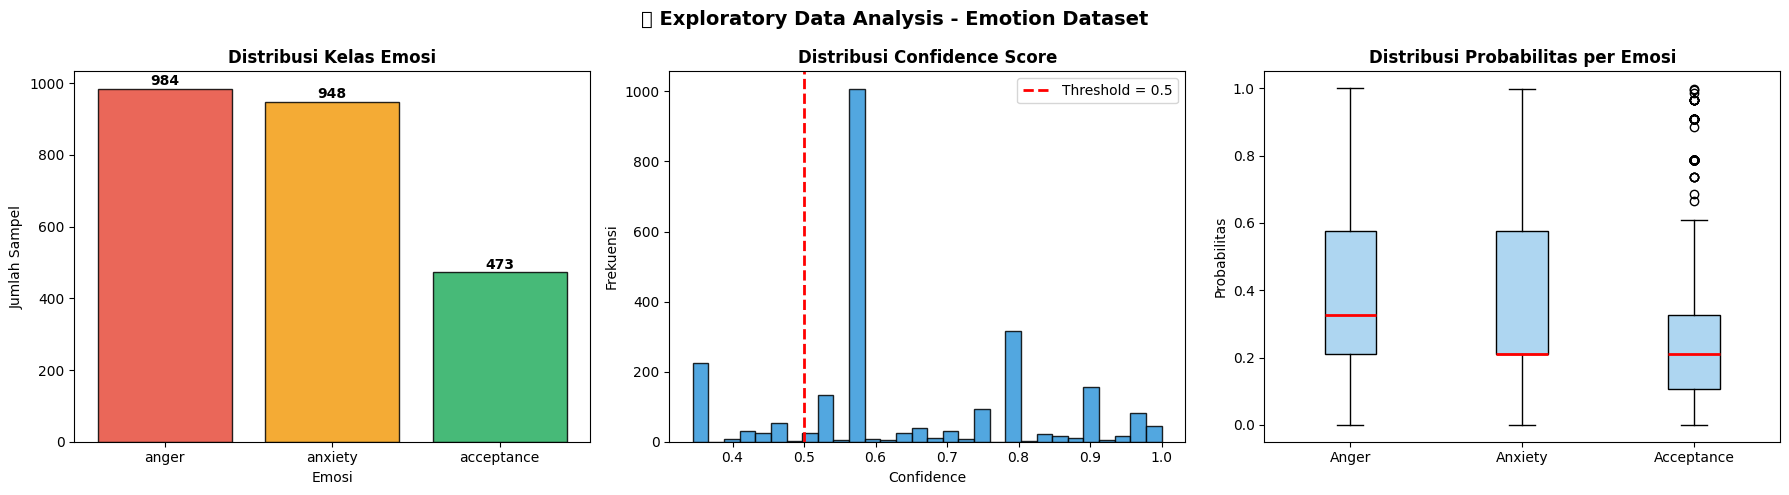

⚠️  CEK CLASS IMBALANCE:
  anger       :  984 sampel (40.9%) ✅ OK
  anxiety     :  948 sampel (39.4%) ✅ OK
  acceptance  :  473 sampel (19.7%) ⚠️ IMBALANCED


In [3]:
# ============================================================
# EDA: DISTRIBUSI EMOSI & CONFIDENCE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Exploratory Data Analysis - Emotion Dataset', fontsize=14, fontweight='bold')

# Plot 1: Distribusi Label Emosi
emotion_counts = df['predicted_emotion'].value_counts()
colors = ['#E74C3C', '#F39C12', '#27AE60']
axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Kelas Emosi', fontweight='bold')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Plot 2: Distribusi Confidence Score
axes[1].hist(df['emotion_confidence'], bins=30, color='#3498DB', edgecolor='black', alpha=0.85)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[1].set_title('Distribusi Confidence Score', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

# Plot 3: Distribusi Probabilitas per Emosi
axes[2].boxplot(
    [df['anger_prob'], df['anxiety_prob'], df['acceptance_prob']],
    labels=['Anger', 'Anxiety', 'Acceptance'],
    patch_artist=True,
    boxprops=dict(facecolor='#AED6F1'),
    medianprops=dict(color='red', linewidth=2)
)
axes[2].set_title('Distribusi Probabilitas per Emosi', fontweight='bold')
axes[2].set_ylabel('Probabilitas')

plt.tight_layout()
plt.show()

# Cek Class Imbalance
print('⚠️  CEK CLASS IMBALANCE:')
for emo, count in emotion_counts.items():
    ratio = count / len(df) * 100
    flag = '⚠️ IMBALANCED' if ratio < 25 else '✅ OK'
    print(f'  {emo:<12}: {count:>4} sampel ({ratio:.1f}%) {flag}')

---
## 🔬 3. Preprocessing & Penyaringan Data

> **Strategi anti-overfitting #1:** Filter data berkualitas rendah (confidence < 0.5) dan hapus duplikat.

In [4]:
# ============================================================
# 3.1 PENYARINGAN DATA (Data Filtering)
# ============================================================
print('🔍 SEBELUM FILTERING:')
print(f'  Total sampel : {len(df):,}')

# Step 1: Hapus duplikat pada teks
df_clean = df.drop_duplicates(subset='text_clean_v1').copy()
print(f'  Setelah drop duplikat: {len(df_clean):,}')

# Step 2: Filter confidence rendah (noise cleaner)
CONFIDENCE_THRESHOLD = 0.5
df_clean = df_clean[df_clean['emotion_confidence'] >= CONFIDENCE_THRESHOLD].copy()
print(f'  Setelah filter confidence >= {CONFIDENCE_THRESHOLD}: {len(df_clean):,}')

# Step 3: Gunakan text_clean_v2 sebagai input utama (lebih konsisten)
df_clean['text'] = df_clean['text_clean_v2'].astype(str).str.strip()

# Step 4: Hapus teks yang terlalu pendek (< 5 kata)
df_clean['word_count'] = df_clean['text'].apply(lambda x: len(x.split()))
df_clean = df_clean[df_clean['word_count'] >= 5].copy()
print(f'  Setelah filter panjang teks >= 5 kata: {len(df_clean):,}')

print()
print('📊 DISTRIBUSI SETELAH FILTERING:')
print(df_clean['predicted_emotion'].value_counts())

# Reset index
df_clean = df_clean.reset_index(drop=True)
print('\n✅ Data bersih siap digunakan!')

🔍 SEBELUM FILTERING:
  Total sampel : 2,405
  Setelah drop duplikat: 2,405
  Setelah filter confidence >= 0.5: 2,058
  Setelah filter panjang teks >= 5 kata: 2,053

📊 DISTRIBUSI SETELAH FILTERING:
predicted_emotion
anger         889
anxiety       705
acceptance    459
Name: count, dtype: int64

✅ Data bersih siap digunakan!


💚 DISTRIBUSI HEALING SCORE:
count    2053.0000
mean        0.2665
std         0.2213
min         0.0000
25%         0.1066
50%         0.2122
75%         0.2766
max         1.0000
Name: healing_score, dtype: float64


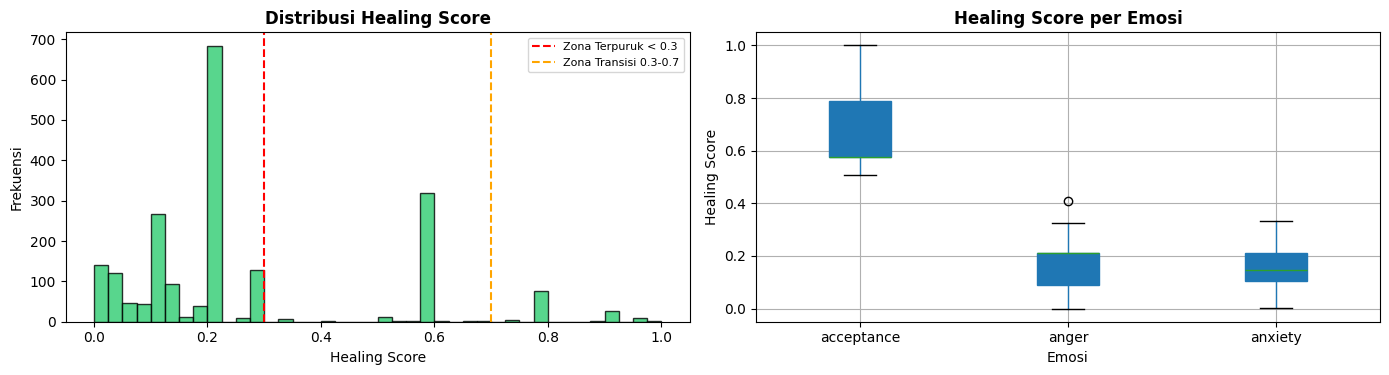


📊 Healing Score per Zona:
healing_score
Terpuruk (0-0.3)      1586
Transisi (0.3-0.7)     345
Menerima (0.7-1.0)     121
Name: count, dtype: int64


In [5]:
# ============================================================
# 3.2 HITUNG HEALING SCORE (Label Regresi)
# ============================================================
# Formula: H_score = P(Acceptance) - (P(Anger) + P(Anxiety)) / 2
# Lalu dinormalisasi ke [0, 1] menggunakan Min-Max Scaler

def compute_healing_score(row):
    """Menghitung Healing Score berdasarkan probabilitas emosi."""
    raw_score = row['acceptance_prob'] - (row['anger_prob'] + row['anxiety_prob']) / 2
    return raw_score

# Hitung raw score
df_clean['healing_score_raw'] = df_clean.apply(compute_healing_score, axis=1)

# Normalisasi ke [0, 1] dengan Min-Max
hs_min = df_clean['healing_score_raw'].min()
hs_max = df_clean['healing_score_raw'].max()
df_clean['healing_score'] = (df_clean['healing_score_raw'] - hs_min) / (hs_max - hs_min)

print('💚 DISTRIBUSI HEALING SCORE:')
print(df_clean['healing_score'].describe().round(4))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean['healing_score'], bins=40, color='#2ECC71', edgecolor='black', alpha=0.8)
axes[0].axvline(0.3, color='red', linestyle='--', label='Zona Terpuruk < 0.3')
axes[0].axvline(0.7, color='orange', linestyle='--', label='Zona Transisi 0.3-0.7')
axes[0].set_title('Distribusi Healing Score', fontweight='bold')
axes[0].set_xlabel('Healing Score')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=8)

# Healing score per emosi
df_clean.boxplot(column='healing_score', by='predicted_emotion', ax=axes[1],
                 patch_artist=True)
axes[1].set_title('Healing Score per Emosi', fontweight='bold')
axes[1].set_xlabel('Emosi')
axes[1].set_ylabel('Healing Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('\n📊 Healing Score per Zona:')
zona_counts = pd.cut(df_clean['healing_score'], bins=[0, 0.3, 0.7, 1.0],
                     labels=['Terpuruk (0-0.3)', 'Transisi (0.3-0.7)', 'Menerima (0.7-1.0)'])
print(zona_counts.value_counts())

In [6]:
# ============================================================
# 3.3 ENCODE LABEL & SPLIT DATA
# ============================================================
label_encoder = LabelEncoder()
df_clean['label'] = label_encoder.fit_transform(df_clean['predicted_emotion'])

print('🏷️  Mapping Label:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {i} → {cls}')

NUM_CLASSES = len(label_encoder.classes_)
CLASS_NAMES = label_encoder.classes_.tolist()

# Stratified Split: 70% train, 15% val, 15% test
X = df_clean['text'].values
y_cls = df_clean['label'].values
y_reg = df_clean['healing_score'].values

X_train, X_temp, y_cls_train, y_cls_temp, y_reg_train, y_reg_temp = train_test_split(
    X, y_cls, y_reg, test_size=0.30, stratify=y_cls, random_state=SEED
)
X_val, X_test, y_cls_val, y_cls_test, y_reg_val, y_reg_test = train_test_split(
    X_temp, y_cls_temp, y_reg_temp, test_size=0.50, stratify=y_cls_temp, random_state=SEED
)

print(f'\n📦 Pembagian Dataset:')
print(f'  Training   : {len(X_train):,} sampel')
print(f'  Validation : {len(X_val):,} sampel')
print(f'  Testing    : {len(X_test):,} sampel')

🏷️  Mapping Label:
  0 → acceptance
  1 → anger
  2 → anxiety

📦 Pembagian Dataset:
  Training   : 1,437 sampel
  Validation : 308 sampel
  Testing    : 308 sampel


---
## 🧠 4. Arsitektur Model Multi-Task Learning

> **Core Architecture:** BERT-based encoder → shared representation → dua head (Klasifikasi + Regresi)

In [7]:
# ============================================================
# 4.1 KONFIGURASI MODEL
# ============================================================

# Pilihan Model Pretrained:
# - 'bert-base-uncased'           → standar, bagus untuk teks pendek
# - 'distilbert-base-uncased'     → lebih ringan, 40% lebih cepat
# - 'roberta-base'                → biasanya lebih akurat
# - 'mental/mental-bert-base-uncased' → domain mental health (paling relevan!)

MODEL_NAME = 'distilbert-base-uncased'  # Ganti sesuai resource GPU kamu
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 10
LR         = 2e-5
DROPOUT    = 0.3

# Bobot loss untuk multi-task (lambda parameter)
LAMBDA_CLS = 0.6   # bobot untuk klasifikasi emosi
LAMBDA_REG = 0.4   # bobot untuk regresi healing score

print('⚙️  Konfigurasi Model:')
print(f'  Pretrained  : {MODEL_NAME}')
print(f'  Max Length  : {MAX_LEN} token')
print(f'  Batch Size  : {BATCH_SIZE}')
print(f'  Epochs      : {EPOCHS}')
print(f'  Learning Rate: {LR}')
print(f'  Dropout     : {DROPOUT}')
print(f'  λ Klasifikasi: {LAMBDA_CLS}')
print(f'  λ Regresi   : {LAMBDA_REG}')

⚙️  Konfigurasi Model:
  Pretrained  : distilbert-base-uncased
  Max Length  : 128 token
  Batch Size  : 16
  Epochs      : 10
  Learning Rate: 2e-05
  Dropout     : 0.3
  λ Klasifikasi: 0.6
  λ Regresi   : 0.4


In [8]:
# ============================================================
# 4.2 DATASET CLASS
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    """
    Dataset untuk Multi-Task Learning:
    - Input  : teks pengguna
    - Output : label emosi (klasifikasi) + healing score (regresi)
    """
    def __init__(self, texts, labels_cls, labels_reg, tokenizer, max_len):
        self.texts       = texts
        self.labels_cls  = labels_cls
        self.labels_reg  = labels_reg
        self.tokenizer   = tokenizer
        self.max_len     = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label_cls'      : torch.tensor(self.labels_cls[idx], dtype=torch.long),
            'label_reg'      : torch.tensor(self.labels_reg[idx], dtype=torch.float)
        }

# Buat DataLoader
def make_loader(X, y_cls, y_reg, shuffle=True):
    dataset = EmotionDataset(X, y_cls, y_reg, tokenizer, MAX_LEN)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

train_loader = make_loader(X_train, y_cls_train, y_reg_train, shuffle=True)
val_loader   = make_loader(X_val,   y_cls_val,   y_reg_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_cls_test,  y_reg_test,  shuffle=False)

print(f'✅ DataLoader berhasil dibuat!')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

✅ DataLoader berhasil dibuat!
   Train batches : 90
   Val batches   : 20
   Test batches  : 20


In [9]:
# ============================================================
# 4.3 ARSITEKTUR MULTI-TASK MODEL
# ============================================================

class MultiTaskEmotionModel(nn.Module):
    """
    Model Multi-Task Learning untuk deteksi emosi & healing score.
    
    Arsitektur:
    [Input Text] → [BERT Encoder] → [CLS Token]
                                         ↓
                              [Shared Dense Layer]
                               ↙              ↘
               [Classification Head]    [Regression Head]
               P(Anger/Anxiety/Accept)   Healing Score [0,1]
    
    Anti-Overfitting strategies:
    - Dropout (0.3) di setiap layer
    - Layer Normalization
    - Freeze bottom BERT layers (partial fine-tuning)
    """
    def __init__(self, model_name, num_classes, dropout=0.3):
        super(MultiTaskEmotionModel, self).__init__()

        # ── BERT Backbone ──────────────────────────────────────
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768 untuk BERT, 768 untuk DistilBERT

        # Freeze 70% layer bawah untuk mencegah overfitting
        # (hanya fine-tune layer atas yang lebih task-spesifik)
        self._freeze_bert_layers(freeze_ratio=0.7)

        # ── Shared Representation Layer ─────────────────────────
        self.shared_layer = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # ── Task 1: Classification Head ──────────────────────────
        # Output: P(Acceptance), P(Anger), P(Anxiety)
        self.cls_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)  # logits
        )

        # ── Task 2: Regression Head ──────────────────────────────
        # Output: Healing Score [0, 1]
        self.reg_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()  # paksa output ke [0, 1]
        )

    def _freeze_bert_layers(self, freeze_ratio=0.7):
        """Freeze sebagian layer BERT untuk mencegah overfitting."""
        all_params = list(self.bert.named_parameters())
        freeze_until = int(len(all_params) * freeze_ratio)
        for i, (name, param) in enumerate(all_params):
            if i < freeze_until:
                param.requires_grad = False
        trainable = sum(p.numel() for p in self.bert.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.bert.parameters())
        print(f'  🔒 BERT layers: {trainable:,}/{total:,} parameter trainable '
              f'({trainable/total*100:.1f}%)')

    def forward(self, input_ids, attention_mask):
        # BERT Encoding → ambil [CLS] token representation
        outputs     = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output  = outputs.last_hidden_state[:, 0, :]   # [batch, hidden]

        # Shared representation
        shared      = self.shared_layer(cls_output)        # [batch, 512]

        # Dua output sekaligus
        cls_logits  = self.cls_head(shared)                # [batch, num_classes]
        reg_output  = self.reg_head(shared).squeeze(-1)    # [batch]

        return cls_logits, reg_output


# Inisialisasi Model
model = MultiTaskEmotionModel(
    model_name  = MODEL_NAME,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n🧠 Model berhasil diinisialisasi!')
print(f'   Total parameter   : {total_params:,}')
print(f'   Trainable parameter: {trainable_params:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  🔒 BERT layers: 13,585,152/66,362,880 parameter trainable (20.5%)

🧠 Model berhasil diinisialisasi!
   Total parameter   : 66,956,292
   Trainable parameter: 14,178,564


---
## 🏋️ 5. Training Loop dengan Anti-Overfitting

In [10]:
# ============================================================
# 5.1 LOSS FUNCTION & OPTIMIZER
# ============================================================

# Hitung class weights untuk atasi imbalance (acceptance << anger/anxiety)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_cls_train),
    y=y_cls_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('⚖️  Class Weights (untuk imbalance):',
      {CLASS_NAMES[i]: round(w, 3) for i, w in enumerate(class_weights)})

# Loss functions
criterion_cls = nn.CrossEntropyLoss(weight=class_weights_tensor)  # weighted CE
criterion_reg = nn.HuberLoss(delta=0.1)   # Huber Loss lebih robust dari MSE

# Optimizer dengan weight decay (L2 regularization)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01   # L2 regularization → anti-overfitting
)

# Learning Rate Scheduler dengan warmup
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = total_steps // 10
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'\n📐 Total training steps : {total_steps:,}')
print(f'   Warmup steps         : {warmup_steps:,}')
print('✅ Optimizer & scheduler siap!')

⚖️  Class Weights (untuk imbalance): {'acceptance': np.float64(1.492), 'anger': np.float64(0.77), 'anxiety': np.float64(0.97)}

📐 Total training steps : 900
   Warmup steps         : 90
✅ Optimizer & scheduler siap!


In [11]:
# ============================================================
# 5.2 TRAINING & EVALUASI FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer, scheduler):
    """Satu epoch training."""
    model.train()
    total_loss, total_cls_loss, total_reg_loss = 0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_cls     = batch['label_cls'].to(DEVICE)
        labels_reg     = batch['label_reg'].to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        cls_logits, reg_output = model(input_ids, attention_mask)

        # Hitung kedua loss
        loss_cls = criterion_cls(cls_logits, labels_cls)
        loss_reg = criterion_reg(reg_output, labels_reg)

        # Total loss: kombinasi berbobot
        loss = LAMBDA_CLS * loss_cls + LAMBDA_REG * loss_reg

        # Backward
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss     += loss.item()
        total_cls_loss += loss_cls.item()
        total_reg_loss += loss_reg.item()

        preds = torch.argmax(cls_logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_cls.cpu().numpy())

    n = len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return total_loss/n, total_cls_loss/n, total_reg_loss/n, acc


@torch.no_grad()
def eval_epoch(model, loader):
    """Evaluasi pada validation/test set."""
    model.eval()
    total_loss, total_cls_loss, total_reg_loss = 0, 0, 0
    all_preds, all_labels, all_reg_preds, all_reg_labels = [], [], [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_cls     = batch['label_cls'].to(DEVICE)
        labels_reg     = batch['label_reg'].to(DEVICE)

        cls_logits, reg_output = model(input_ids, attention_mask)

        loss_cls = criterion_cls(cls_logits, labels_cls)
        loss_reg = criterion_reg(reg_output, labels_reg)
        loss     = LAMBDA_CLS * loss_cls + LAMBDA_REG * loss_reg

        total_loss     += loss.item()
        total_cls_loss += loss_cls.item()
        total_reg_loss += loss_reg.item()

        preds = torch.argmax(cls_logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_cls.cpu().numpy())
        all_reg_preds.extend(reg_output.cpu().numpy())
        all_reg_labels.extend(labels_reg.cpu().numpy())

    n   = len(loader)
    acc = accuracy_score(all_labels, all_preds)
    mae = mean_absolute_error(all_reg_labels, all_reg_preds)
    return (total_loss/n, total_cls_loss/n, total_reg_loss/n,
            acc, mae, all_preds, all_labels, all_reg_preds, all_reg_labels)

print('✅ Training & evaluasi functions siap!')

✅ Training & evaluasi functions siap!


In [12]:
# ============================================================
# 5.3 MAIN TRAINING LOOP
# ============================================================

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_mae':    []
}

best_val_acc  = 0.0
best_val_mae  = float('inf')
PATIENCE      = 3          # early stopping patience
patience_cnt  = 0
BEST_MODEL_PATH = 'best_model.pt'

print('🚀 Memulai Training...\n')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Val Loss":>10} | {"Train Acc":>10} | {"Val Acc":>10} | {"Val MAE":>8}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    # Training
    tr_loss, tr_cls, tr_reg, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)

    # Validasi
    vl_loss, vl_cls, vl_reg, vl_acc, vl_mae, _, _, _, _ = eval_epoch(model, val_loader)

    # Simpan history
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_mae'].append(vl_mae)

    # Cek apakah model terbaik (berdasarkan val_acc)
    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_val_mae = vl_mae
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        patience_cnt = 0
        flag = '⭐ BEST'
    else:
        patience_cnt += 1
        flag = f'(patience {patience_cnt}/{PATIENCE})'

    print(f'{epoch:>5} | {tr_loss:>10.4f} | {vl_loss:>10.4f} | '
          f'{tr_acc:>9.1%} | {vl_acc:>9.1%} | {vl_mae:>8.4f}  {flag}')

    # Early Stopping
    if patience_cnt >= PATIENCE:
        print(f'\n⏹️  Early stopping di epoch {epoch}. Tidak ada peningkatan selama {PATIENCE} epoch.')
        break

print(f'\n🏆 Best Model → Val Acc: {best_val_acc:.1%} | Val MAE: {best_val_mae:.4f}')

# Target check
print(f'\n🎯 Target Check:')
print(f'   Akurasi ≥ 85% : {"✅ TERCAPAI" if best_val_acc >= 0.85 else "❌ Belum"} ({best_val_acc:.1%})')
print(f'   MAE ≤ 0.02    : {"✅ TERCAPAI" if best_val_mae <= 0.02 else "❌ Belum"} ({best_val_mae:.4f})')

🚀 Memulai Training...

Epoch | Train Loss |   Val Loss |  Train Acc |    Val Acc |  Val MAE
-----------------------------------------------------------------
    1 |     0.6853 |     0.6063 |     37.5% |     58.4% |   0.1625  ⭐ BEST
    2 |     0.5512 |     0.5048 |     59.5% |     66.6% |   0.1622  ⭐ BEST
    3 |     0.4249 |     0.4415 |     70.6% |     69.5% |   0.1598  ⭐ BEST
    4 |     0.3734 |     0.4052 |     74.4% |     72.1% |   0.1552  ⭐ BEST
    5 |     0.3278 |     0.4151 |     79.1% |     72.7% |   0.1518  ⭐ BEST
    6 |     0.2929 |     0.3927 |     81.9% |     75.3% |   0.1471  ⭐ BEST
    7 |     0.2690 |     0.3890 |     83.2% |     76.9% |   0.1444  ⭐ BEST
    8 |     0.2433 |     0.3995 |     86.4% |     76.6% |   0.1416  (patience 1/3)
    9 |     0.2376 |     0.3963 |     86.2% |     78.2% |   0.1419  ⭐ BEST
   10 |     0.2288 |     0.3903 |     87.8% |     78.2% |   0.1401  (patience 1/3)

🏆 Best Model → Val Acc: 78.2% | Val MAE: 0.1419

🎯 Target Check:
   Akurasi

---
## 📈 6. Visualisasi Training & Evaluasi Final

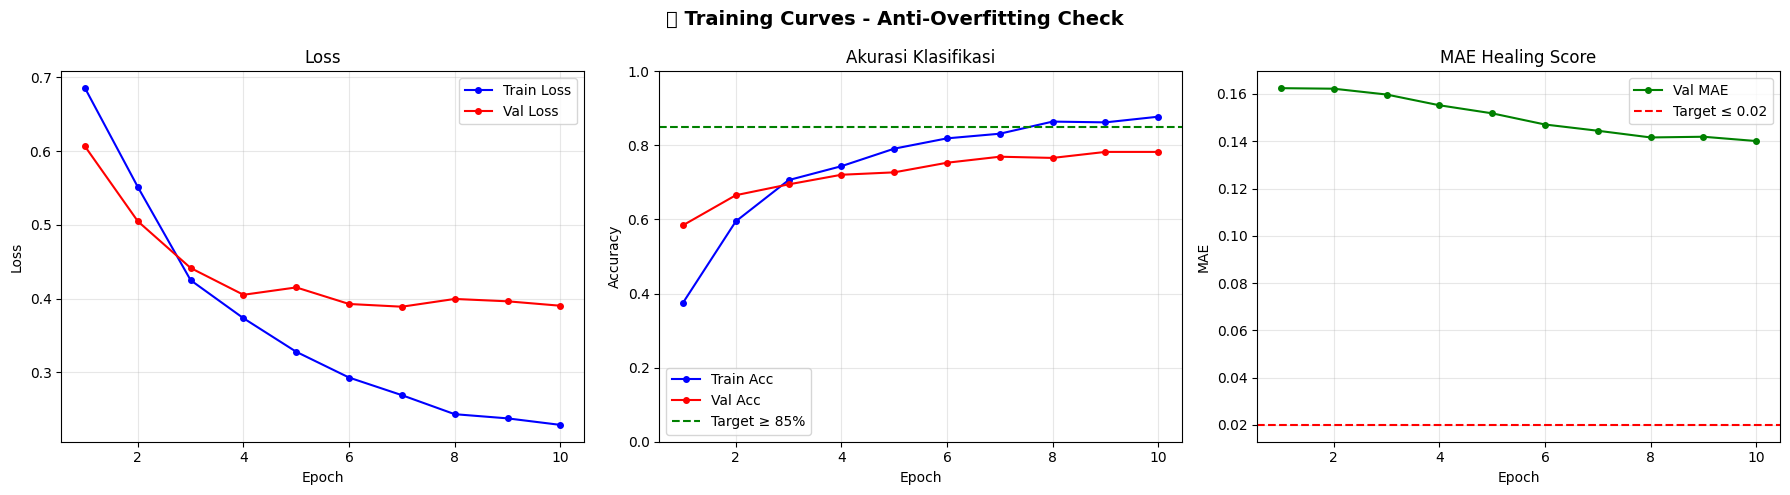


🔍 Overfitting Check:
   Train Acc: 87.8%
   Val Acc  : 78.2%
   Gap      : 9.5% ⚠️  SEDIKIT OVERFITTING (gap 5-10%)


In [13]:
# ============================================================
# 6.1 KURVA TRAINING
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📈 Training Curves - Anti-Overfitting Check', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
axes[1].axhline(0.85, color='green', linestyle='--', linewidth=1.5, label='Target ≥ 85%')
axes[1].set_title('Akurasi Klasifikasi')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MAE
axes[2].plot(epochs_range, history['val_mae'], 'g-o', label='Val MAE', markersize=4)
axes[2].axhline(0.02, color='red', linestyle='--', linewidth=1.5, label='Target ≤ 0.02')
axes[2].set_title('MAE Healing Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MAE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cek overfitting
if len(history['train_loss']) > 1:
    gap = history['train_acc'][-1] - history['val_acc'][-1]
    print(f'\n🔍 Overfitting Check:')
    print(f'   Train Acc: {history["train_acc"][-1]:.1%}')
    print(f'   Val Acc  : {history["val_acc"][-1]:.1%}')
    print(f'   Gap      : {gap:.1%}', end=' ')
    if gap < 0.05:
        print('✅ TIDAK OVERFITTING (gap < 5%)')
    elif gap < 0.10:
        print('⚠️  SEDIKIT OVERFITTING (gap 5-10%)')
    else:
        print('❌ OVERFITTING (gap > 10%)')

In [14]:
# ============================================================
# 6.2 EVALUASI FINAL PADA TEST SET
# ============================================================

# Load best model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

_, _, _, test_acc, test_mae, preds, labels, reg_preds, reg_labels = eval_epoch(model, test_loader)

print('=' * 55)
print('🎯 HASIL AKHIR PADA TEST SET')
print('=' * 55)
print(f'  Akurasi Klasifikasi : {test_acc:.4f} ({test_acc:.1%})')
print(f'  MAE Healing Score   : {test_mae:.4f}')
print(f'  F1-Score (macro)    : {f1_score(labels, preds, average="macro"):.4f}')
print()

# Classification Report
print('📊 LAPORAN KLASIFIKASI DETAIL:')
print(classification_report(labels, preds, target_names=CLASS_NAMES))

# Target check
print('\n🎯 STATUS TARGET PROYEK:')
print(f"   [{'✅' if test_acc >= 0.85 else '❌'}] Akurasi ≥ 85% : {test_acc:.1%}")
print(f"   [{'✅' if test_mae <= 0.02 else '❌'}] MAE ≤ 0.02    : {test_mae:.4f}")

🎯 HASIL AKHIR PADA TEST SET
  Akurasi Klasifikasi : 0.7468 (74.7%)
  MAE Healing Score   : 0.1291
  F1-Score (macro)    : 0.7263

📊 LAPORAN KLASIFIKASI DETAIL:
              precision    recall  f1-score   support

  acceptance       0.59      0.64      0.62        69
       anger       0.83      0.81      0.82       134
     anxiety       0.75      0.73      0.74       105

    accuracy                           0.75       308
   macro avg       0.73      0.73      0.73       308
weighted avg       0.75      0.75      0.75       308


🎯 STATUS TARGET PROYEK:
   [❌] Akurasi ≥ 85% : 74.7%
   [❌] MAE ≤ 0.02    : 0.1291


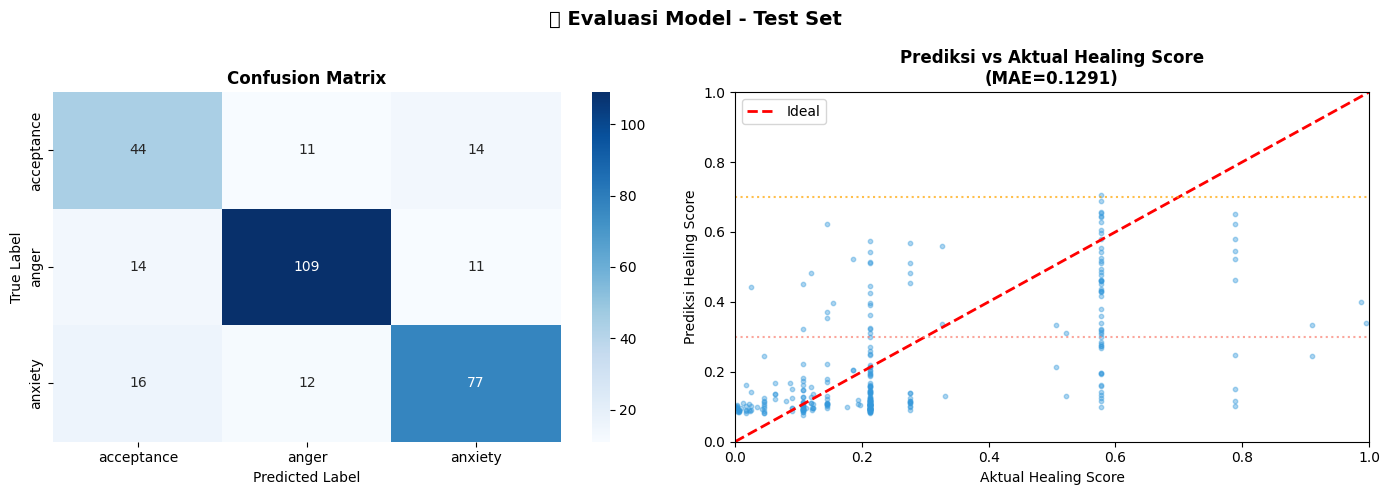

In [15]:
# ============================================================
# 6.3 CONFUSION MATRIX & SCATTER HEALING SCORE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Evaluasi Model - Test Set', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Scatter: Prediksi vs Aktual Healing Score
axes[1].scatter(reg_labels, reg_preds, alpha=0.4, s=10, color='#3498DB')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal')
axes[1].axhline(0.3, color='salmon', linestyle=':', alpha=0.7)
axes[1].axhline(0.7, color='orange', linestyle=':', alpha=0.7)
axes[1].set_title(f'Prediksi vs Aktual Healing Score\n(MAE={test_mae:.4f})', fontweight='bold')
axes[1].set_xlabel('Aktual Healing Score')
axes[1].set_ylabel('Prediksi Healing Score')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

---
## 💬 7. Mesin Pengambil Keputusan: Respons Chatbot

> Implementasi sistem respons berdasarkan Healing Score + Confidence Score

In [16]:
# ============================================================
# 7.1 HEALING SCORE CALCULATOR & CHATBOT RESPONDER
# ============================================================

# Normalization constants dari training data
HS_MIN = hs_min
HS_MAX = hs_max


def predict_emotion_and_healing(text, model, tokenizer, device=DEVICE):
    """
    Memprediksi emosi dan healing score dari teks input.
    
    Returns:
        dict: {
            'predicted_emotion' : str,
            'probabilities'     : dict {emotion: prob},
            'confidence'        : float,
            'healing_score'     : float,
            'healing_zone'      : str
        }
    """
    model.eval()
    encoding = tokenizer(
        text, max_length=MAX_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        cls_logits, healing_score_pred = model(input_ids, attention_mask)

    probs = F.softmax(cls_logits, dim=-1).squeeze().cpu().numpy()
    healing_score = float(healing_score_pred.squeeze().cpu().numpy())

    prob_dict       = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    predicted_idx   = int(np.argmax(probs))
    predicted_emo   = CLASS_NAMES[predicted_idx]
    confidence      = float(probs[predicted_idx])

    # Tentukan zona healing
    if healing_score < 0.3:
        zone = 'TERPURUK'
    elif healing_score < 0.7:
        zone = 'TRANSISI'
    else:
        zone = 'MENERIMA'

    return {
        'predicted_emotion' : predicted_emo,
        'probabilities'     : prob_dict,
        'confidence'        : confidence,
        'healing_score'     : healing_score,
        'healing_zone'      : zone
    }


def get_chatbot_response(prediction_result):
    """
    Mesin pengambil keputusan respons chatbot.
    
    Logic:
    - Confidence < 0.5  → Fallback (minta klarifikasi)
    - Score 0.0-0.3     → Empati & Validasi
    - Score 0.3-0.7     → Refleksi & Perspektif Baru
    - Score 0.7-1.0     → Afirmasi & Motivasi
    """
    conf  = prediction_result['confidence']
    score = prediction_result['healing_score']
    zone  = prediction_result['healing_zone']
    emo   = prediction_result['predicted_emotion']

    # ─── Protokol Fallback ───────────────────────────────────
    if conf < 0.5:
        return {
            'tone'     : 'FALLBACK',
            'response' : (
                "Aku ingin benar-benar memahami apa yang kamu rasakan. "
                "Boleh ceritakan lebih detail situasi yang kamu alami sekarang?"
            ),
            'reason'   : f'Confidence rendah ({conf:.1%}), meminta klarifikasi'
        }

    # ─── Zona Terpuruk (0.0 - 0.3): Empati & Validasi ───────
    if zone == 'TERPURUK':
        responses = {
            'anger'      : (
                "Rasa marah yang kamu rasakan itu valid. Ketika seseorang yang kita cintai "
                "menyakiti kita, wajar sekali jika ada bagian dari kita yang merasa marah dan "
                "terluka. Aku di sini bersamamu. Mau cerita lebih?"
            ),
            'anxiety'    : (
                "Aku bisa merasakan betapa beratnya perasaan yang kamu tanggung sekarang. "
                "Rasa cemas dan tidak pasti itu nyata, dan kamu tidak harus menanggungnya "
                "sendirian. Ambil napas sejenak. Aku di sini untuk mendengarkan."
            ),
            'acceptance' : (
                "Meski terasa berat, kamu sudah menunjukkan keberanian yang luar biasa hanya "
                "dengan mau membuka diri. Perasaan yang kamu alami sekarang adalah bagian "
                "dari proses, dan itu tidak apa-apa."
            )
        }
        return {
            'tone'     : 'EMPATI & VALIDASI',
            'response' : responses.get(emo.lower(), responses['anxiety']),
            'reason'   : f'Healing Score {score:.2f} → Zona Terpuruk, butuh empati'
        }

    # ─── Zona Transisi (0.3 - 0.7): Refleksi ────────────────
    elif zone == 'TRANSISI':
        responses = {
            'anger'      : (
                "Aku dengar kamu. Rasa marah itu sering kali muncul karena kita peduli, "
                "dan kepedulian itu adalah tanda kekuatan. Bagaimana menurutmu, apa yang "
                "paling kamu butuhkan dari dirimu sendiri saat ini?"
            ),
            'anxiety'    : (
                "Kecemasan itu wajar hadir di masa transisi seperti ini. Kadang kita takut "
                "karena hal-hal yang belum pasti. Kalau kita coba lihat dari sisi lain: "
                "hal apa yang sebenarnya sudah kamu lakukan dengan baik untuk dirimu sendiri?"
            ),
            'acceptance' : (
                "Sepertinya kamu sudah mulai menemukan titik keseimbangan dalam dirimu. "
                "Ini adalah momen yang penting. Apa satu hal kecil yang bisa kamu lakukan "
                "hari ini untuk merawat dirimu sendiri?"
            )
        }
        return {
            'tone'     : 'REFLEKSI & PERSPEKTIF BARU',
            'response' : responses.get(emo.lower(), responses['acceptance']),
            'reason'   : f'Healing Score {score:.2f} → Zona Transisi, butuh refleksi'
        }

    # ─── Zona Menerima (0.7 - 1.0): Afirmasi & Motivasi ─────
    else:
        return {
            'tone'     : 'AFIRMASI & MOTIVASI',
            'response' : (
                "Kamu sudah menempuh perjalanan yang tidak mudah, dan aku benar-benar "
                "kagum dengan ketangguhanmu. Penerimaan seperti yang kamu tunjukkan ini "
                "adalah tanda bahwa kamu siap untuk babak baru yang lebih indah. "
                "Masa depanmu penuh dengan kemungkinan — dan kamu pantas mendapatkan "
                "semua kebaikan yang akan datang. 🌱"
            ),
            'reason'   : f'Healing Score {score:.2f} → Zona Menerima, saatnya motivasi'
        }


print('✅ Chatbot decision engine siap!')

✅ Chatbot decision engine siap!


In [17]:
# ============================================================
# 7.2 DEMO CHATBOT: SIMULASI PERCAKAPAN
# ============================================================

def chat_demo(user_text):
    """Tampilkan output lengkap dari satu input pengguna."""
    print('\n' + '═' * 60)
    print(f'💬 USER: "{user_text}"')
    print('─' * 60)

    # Prediksi
    result  = predict_emotion_and_healing(user_text, model, tokenizer)
    resp    = get_chatbot_response(result)

    # Probabilitas emosi
    probs = result['probabilities']
    print('📊 ANALISIS EMOSI:')
    for emo, prob in sorted(probs.items(), key=lambda x: -x[1]):
        bar = '█' * int(prob * 20)
        print(f'  {emo:<12}: {prob:.1%}  {bar}')

    # Healing Score
    hs = result['healing_score']
    bar_hs = '█' * int(hs * 20)
    print(f'\n💚 HEALING SCORE : {hs:.3f}  [{bar_hs:<20}]')
    print(f'   Confidence    : {result["confidence"]:.1%}')
    print(f'   Zona          : {result["healing_zone"]}')
    print(f'   Tone Respons  : {resp["tone"]}')
    print(f'   Alasan        : {resp["reason"]}')

    print(f'\n🤖 CHATBOT:')
    print(f'   "{resp["response"]}"')
    print('═' * 60)


# ── Demo dengan berbagai skenario ──────────────────────────
test_inputs = [
    # Zona Terpuruk
    "I feel so betrayed and hurt, I can't stop crying. How could they do this to me?",
    # Zona Transisi
    "I'm still scared about being alone, but I think I'm slowly getting better",
    # Zona Menerima
    "I realize now that everything happened for a reason. I feel at peace and ready to move forward",
    # Confidence rendah (ambigu)
    "today is a day"
]

for text in test_inputs:
    chat_demo(text)


════════════════════════════════════════════════════════════
💬 USER: "I feel so betrayed and hurt, I can't stop crying. How could they do this to me?"
────────────────────────────────────────────────────────────
📊 ANALISIS EMOSI:
  anger       : 97.6%  ███████████████████
  anxiety     : 1.8%  
  acceptance  : 0.6%  

💚 HEALING SCORE : 0.087  [█                   ]
   Confidence    : 97.6%
   Zona          : TERPURUK
   Tone Respons  : EMPATI & VALIDASI
   Alasan        : Healing Score 0.09 → Zona Terpuruk, butuh empati

🤖 CHATBOT:
   "Rasa marah yang kamu rasakan itu valid. Ketika seseorang yang kita cintai menyakiti kita, wajar sekali jika ada bagian dari kita yang merasa marah dan terluka. Aku di sini bersamamu. Mau cerita lebih?"
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
💬 USER: "I'm still scared about being alone, but I think I'm slowly getting better"
────────────────────────────────────────────────

---
## 🛡️ 8. Strategi Anti-Overfitting - Ringkasan & Ablation

In [18]:
# ============================================================
# 8. RINGKASAN STRATEGI ANTI-OVERFITTING
# ============================================================

strategies = {
    'Data Level': [
        ('Filter confidence < 0.5', 'Buang sampel ambigu/noise dari dataset'),
        ('Drop duplikat', 'Cegah model menghafal sampel identik'),
        ('Filter teks pendek < 5 kata', 'Buang sampel tidak informatif'),
        ('Class weights (imbalance)', 'Kompensasi kelas acceptance yang lebih sedikit'),
        ('Stratified split', 'Distribusi kelas merata di train/val/test'),
    ],
    'Model Level': [
        ('Dropout = 0.3', 'Regularisasi acak di setiap layer'),
        ('Layer Normalization', 'Stabilisasi gradien, cegah internal covariate shift'),
        ('Freeze 70% BERT layers', 'Hanya fine-tune layer atas yang task-spesifik'),
        ('Shared representation', 'Layer bersama memaksa generalisasi antar task'),
    ],
    'Training Level': [
        ('Weight Decay = 0.01 (L2)', 'Penalti parameter besar, cegah overfitting'),
        ('Gradient Clipping (max=1.0)', 'Cegah exploding gradients'),
        ('Warmup + Linear LR Decay', 'Learning rate adaptif, konvergensi lebih stabil'),
        ('Early Stopping (patience=3)', 'Hentikan training saat val tidak membaik'),
        ('Huber Loss untuk regresi', 'Lebih robust terhadap outlier daripada MSE'),
    ]
}

print('╔' + '═'*58 + '╗')
print('║  🛡️  STRATEGI ANTI-OVERFITTING YANG DIIMPLEMENTASI       ║')
print('╠' + '═'*58 + '╣')
for category, items in strategies.items():
    print(f'║  📂 {category:<54}║')
    for technique, explanation in items:
        print(f'║     ✓ {technique:<24} : {explanation:<22}  ║'[:61] + '  ║')
    print('║' + ' '*58 + '║')
print('╚' + '═'*58 + '╝')

print(f'\n📊 RINGKASAN PERFORMA FINAL:')
print(f'   Test Accuracy : {test_acc:.4f} ({test_acc:.1%})')
print(f'   Test MAE      : {test_mae:.4f}')
print(f'   F1 Macro      : {f1_score(labels, preds, average="macro"):.4f}')

╔══════════════════════════════════════════════════════════╗
║  🛡️  STRATEGI ANTI-OVERFITTING YANG DIIMPLEMENTASI       ║
╠══════════════════════════════════════════════════════════╣
║  📂 Data Level                                            ║
║     ✓ Filter confidence < 0.5  : Buang sampel ambigu/noise   ║
║     ✓ Drop duplikat            : Cegah model menghafal samp  ║
║     ✓ Filter teks pendek < 5 kata : Buang sampel tidak info  ║
║     ✓ Class weights (imbalance) : Kompensasi kelas acceptan  ║
║     ✓ Stratified split         : Distribusi kelas merata di  ║
║                                                          ║
║  📂 Model Level                                           ║
║     ✓ Dropout = 0.3            : Regularisasi acak di setia  ║
║     ✓ Layer Normalization      : Stabilisasi gradien, cegah  ║
║     ✓ Freeze 70% BERT layers   : Hanya fine-tune layer atas  ║
║     ✓ Shared representation    : Layer bersama memaksa gene  ║
║                                                

---
## 💾 9. Simpan Model untuk Deployment

In [19]:
# ============================================================
# 9. SIMPAN ARTIFACTS UNTUK DEPLOYMENT
# ============================================================
import json, pickle

# 1. Model weights (sudah disimpan sebagai best_model.pt)
print('💾 Menyimpan artifacts...')

# 2. Konfigurasi model
config = {
    'model_name'   : MODEL_NAME,
    'num_classes'  : NUM_CLASSES,
    'class_names'  : CLASS_NAMES,
    'max_len'      : MAX_LEN,
    'dropout'      : DROPOUT,
    'hs_min'       : float(HS_MIN),
    'hs_max'       : float(HS_MAX),
    'confidence_threshold': 0.5,
    'healing_zones': {
        'terpuruk' : [0.0, 0.3],
        'transisi' : [0.3, 0.7],
        'menerima' : [0.7, 1.0]
    },
    'test_accuracy': float(test_acc),
    'test_mae'     : float(test_mae)
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# 3. Label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print('✅ Artifacts tersimpan:')
print('   📦 best_model.pt        → Model weights (PyTorch)')
print('   📋 model_config.json    → Konfigurasi & metadata model')
print('   🏷️  label_encoder.pkl   → Label encoder (idx ↔ nama emosi)')
print()
print('📌 Cara load untuk inference:')
print("""
import torch, json
from transformers import AutoTokenizer

config    = json.load(open('model_config.json'))
tokenizer = AutoTokenizer.from_pretrained(config['model_name'])
model     = MultiTaskEmotionModel(config['model_name'], config['num_classes'])
model.load_state_dict(torch.load('best_model.pt', map_location='cpu'))
model.eval()
# → Siap untuk inferensi!
""")

💾 Menyimpan artifacts...
✅ Artifacts tersimpan:
   📦 best_model.pt        → Model weights (PyTorch)
   📋 model_config.json    → Konfigurasi & metadata model
   🏷️  label_encoder.pkl   → Label encoder (idx ↔ nama emosi)

📌 Cara load untuk inference:

import torch, json
from transformers import AutoTokenizer

config    = json.load(open('model_config.json'))
tokenizer = AutoTokenizer.from_pretrained(config['model_name'])
model     = MultiTaskEmotionModel(config['model_name'], config['num_classes'])
model.load_state_dict(torch.load('best_model.pt', map_location='cpu'))
model.eval()
# → Siap untuk inferensi!



---

## ✅ Ringkasan Proyek

| Komponen | Detail |
|---|---|
| **Model** | DistilBERT + Multi-Task Head (Klasifikasi + Regresi) |
| **Task 1** | Klasifikasi 3 emosi: Acceptance, Anger, Anxiety |
| **Task 2** | Regresi Healing Score [0.0 – 1.0] |
| **Anti-Overfitting** | Dropout, L2 Reg, Layer Freeze, Early Stopping, Data Filtering |
| **Respons Chatbot** | 3 zona (Empati / Refleksi / Motivasi) + Fallback |
| **Target** | Akurasi ≥ 85% & MAE ≤ 0.02 |

### Zona Healing Score
```
0.0 ───────── 0.3 ───────── 0.7 ───────── 1.0
  TERPURUK        TRANSISI        MENERIMA
  (Empati)       (Refleksi)     (Motivasi)
```